In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
# ClickHouse connection parameters
CLICKHOUSE_HOST = "http://localhost:8123"
CLICKHOUSE_USER = "default"
CLICKHOUSE_PASSWORD = "model-gateway-1"
CLICKHOUSE_DATABASE = "modelgateway1"

In [3]:
def query_clickhouse(sql):
    """Execute a query against ClickHouse"""
    url = f"{CLICKHOUSE_HOST}/?default_format=JSON&database={CLICKHOUSE_DATABASE}"
    auth = (CLICKHOUSE_USER, CLICKHOUSE_PASSWORD)
    response = requests.post(url, data=sql, auth=auth)
    response.raise_for_status()
    return response.json()

In [4]:
# Explore all data with response_id extracted from response_payload
sql = """
SELECT 
    id,
    model,
    duration_completed,
    response_payload.id AS response_id
FROM query_logs
ORDER BY id DESC
"""
result = query_clickhouse(sql)
data = result.get('data', [])
df = pd.DataFrame(data)
df

,id,model,duration_completed,response_id
0,3331475149932203281,claude-sonnet-4-6,7619,05f6d1793761edad12e7d92c1585b033
1,3331475096643570916,claude-sonnet-4-6,1174,05f6d1734458a378089568ab20d8086a
2,3331475046240619666,claude-sonnet-4-6,2051,05f6d16551278659b0dec0b514d65cd5
3,3331474972320205934,claude-sonnet-4-6,1507,05f6d155f27ca6c0eaaa63c535bde755
4,3331474944398724142,claude-sonnet-4-6,3935,05f6d14ced14db2e179e40439114c713
...,...,...,...,...
237,3331211660244287862,claude-sonnet-4-6,1112,05f5dc1c4a890ae571da9c6d98b7674d
238,3331211621195317541,claude-sonnet-4-6,12430,05f5dc05a6805d44cf25c8fc0beb1406
239,3331211546561872109,claude-sonnet-4-6,973,05f5dc00288be94bb1412da9446ecb71
240,3331211524202037408,claude-sonnet-4-6,1975,05f5dbfaf0880d173cf05d57ce7f3a09


In [ ]:
# Filter
start_id = 3331229494005465783
end_id = 3331229943613884106

# Also fetch token columns
if start_id and end_id:
    sql = f"""
    SELECT
        id,
        model,
        duration_completed,
        input_token,
        output_token,
        cache_token,
        response_payload.id AS response_id
    FROM query_logs
    WHERE id >= {start_id} AND id <= {end_id}
    ORDER BY id ASC
    """
elif start_id:
    sql = f"""
    SELECT
        id,
        model,
        duration_completed,
        input_token,
        output_token,
        cache_token,
        response_payload.id AS response_id
    FROM query_logs
    WHERE id >= {start_id}
    ORDER BY id ASC
    """
elif end_id:
    sql = f"""
    SELECT
        id,
        model,
        duration_completed,
        input_token,
        output_token,
        cache_token,
        response_payload.id AS response_id
    FROM query_logs
    WHERE id <= {end_id}
    ORDER BY id ASC
    """
else:
    sql = """
    SELECT
        id,
        model,
        duration_completed,
        input_token,
        output_token,
        cache_token,
        response_payload.id AS response_id
    FROM query_logs
    ORDER BY id ASC
    """

result = query_clickhouse(sql)
data = result.get('data', [])
df_filtered = pd.DataFrame(data)
print(f"Found {len(df_filtered)} records")
df_filtered

Found 54 records


,id,model,duration_completed,input_token,output_token,cache_token,response_id
0,3331472113092528050,claude-sonnet-4-6,8187,6416,252,14336,msg_202603041040397544a0de4bdf4a8e
1,3331472221326540825,claude-sonnet-4-6,3642,197,247,0,05f6cec309201772e85eae4154bbef45
2,3331472269250658378,claude-haiku-4-5-20251001,2680,140,199,0,05f6ceca8d5fe8ff360754da8da6bb6b
3,3331472312770756776,claude-haiku-4-5-20251001,1622,1559,149,11925,05f6ced63b846f9268550a68b8326548
4,3331472358773883082,claude-haiku-4-5-20251001,1485,258,170,12068,05f6cee0e5f1e81660fae86255793be4
5,3331472391342653752,claude-haiku-4-5-20251001,3201,7039,156,13691,05f6ceeb203791f46b29785b6f573fc3
6,3331472431675081046,claude-haiku-4-5-20251001,2968,2323,152,13963,05f6cef30384f02d22e5023c44f7e02b
7,3331472457520382354,claude-haiku-4-5-20251001,2255,240,106,21037,05f6cefd1a24ce8c36b29cd00361e02e
8,3331472502143582706,claude-haiku-4-5-20251001,2376,4355,138,23381,05f6cf037262165967fc4a112564ac06
9,3331472556984107583,claude-haiku-4-5-20251001,2211,1676,123,23638,05f6cf0e00e0f2304d223b55d31965ca


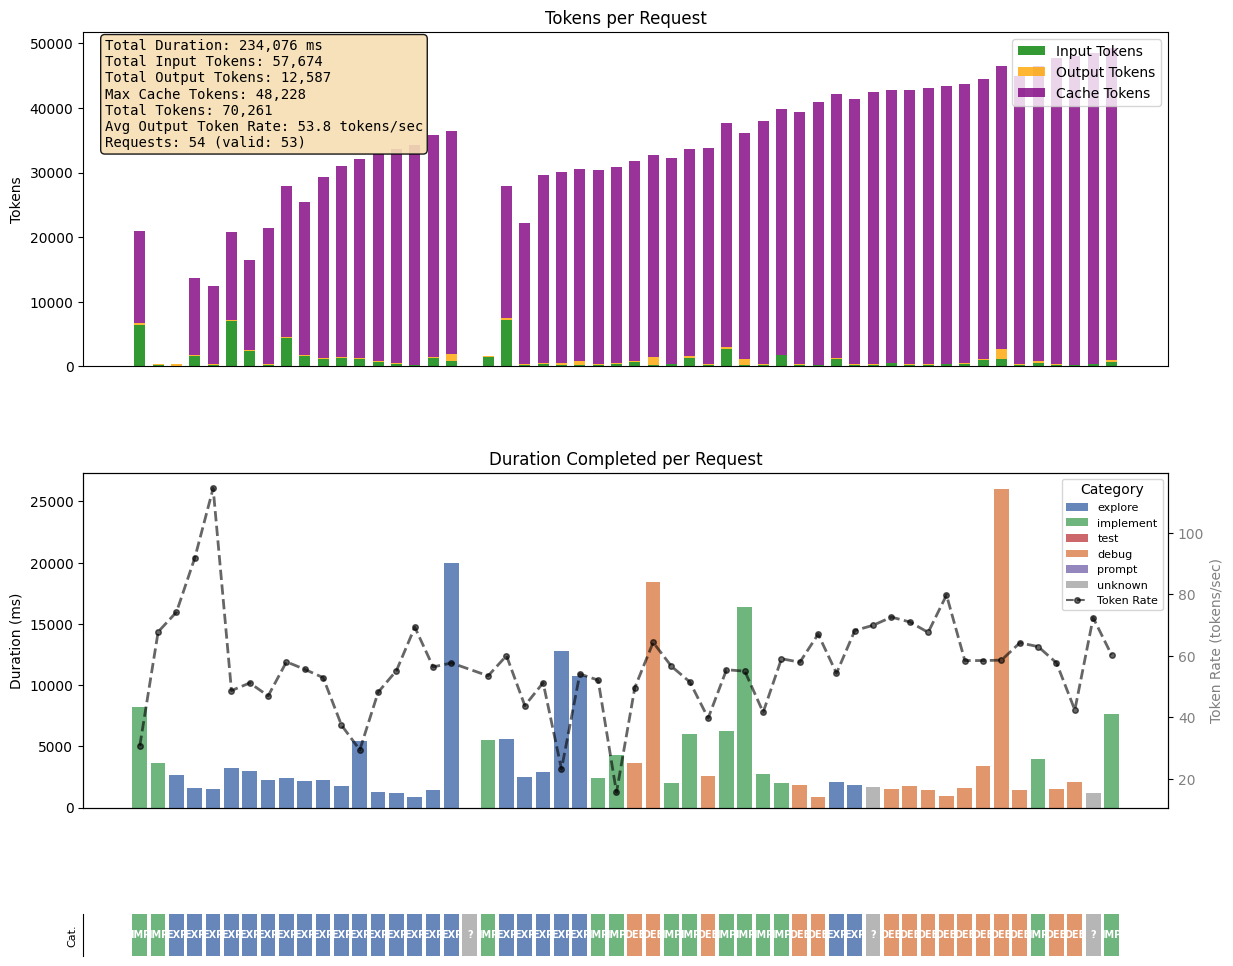

In [ ]:
# Plot tokens, duration, and category strip
import numpy as np
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

# Load categories
try:
    with open("categories.json") as f:
        categories_map = json.load(f)
except (FileNotFoundError, json.JSONDecodeError):
    categories_map = {}

CATEGORY_COLORS = {
    "explore":   "#4C72B0",
    "implement": "#55A868",
    "test":      "#C44E52",
    "debug":     "#DD8452",
    "prompt":    "#8172B2",
}
DEFAULT_COLOR = "#AAAAAA"

fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(3, 1, height_ratios=[4, 4, 0.5], hspace=0.45)

ax_tok = fig.add_subplot(gs[0])
ax_dur = fig.add_subplot(gs[1], sharex=ax_tok)
ax_cat = fig.add_subplot(gs[2], sharex=ax_tok)

# Summary statistics
df_valid = df_filtered[df_filtered['duration_completed'] > 0]
total_duration = df_filtered['duration_completed'].sum()
total_input = df_filtered['input_token'].sum()
total_output = df_filtered['output_token'].sum()
max_cache = df_filtered['cache_token'].max()
total_tokens = total_input + total_output

x = list(range(len(df_filtered)))
x_labels = [str(rid)[:8] if pd.notna(rid) else str(i) for i, rid in enumerate(df_filtered['id'].values)]

# Category per row
row_categories = [categories_map.get(str(r_id), None) for r_id in df_filtered['id'].values]
bar_colors = [CATEGORY_COLORS.get(cat, DEFAULT_COLOR) for cat in row_categories]

# Token rate
token_rate = np.array([np.nan if d == 0 else o / (d / 1000.0)
                       for d, o in zip(df_filtered['duration_completed'].values, df_filtered['output_token'].values)])

# Tokens per Request
bar_width = 0.6
ax_tok.bar(x, df_filtered['input_token'].values, bar_width, label='Input Tokens', color='green', alpha=0.8)
ax_tok.bar(x, df_filtered['output_token'].values, bar_width, bottom=df_filtered['input_token'].values, label='Output Tokens', color='orange', alpha=0.8)
ax_tok.bar(x, df_filtered['cache_token'].values, bar_width,
           bottom=df_filtered['input_token'].values + df_filtered['output_token'].values,
           label='Cache Tokens', color='purple', alpha=0.8)
ax_tok.set_ylabel('Tokens')
ax_tok.set_title('Tokens per Request')
ax_tok.legend(loc='upper right')
plt.setp(ax_tok.get_xticklabels(), visible=False)

# Summary box on token chart
avg_token_rate = df_valid['output_token'].sum() / (df_valid['duration_completed'].sum() / 1000) if len(df_valid) > 0 else 0
summary_text = f"""Total Duration: {total_duration:,} ms
Total Input Tokens: {total_input:,}
Total Output Tokens: {total_output:,}
Max Cache Tokens: {max_cache:,}
Total Tokens: {total_tokens:,}
Avg Output Token Rate: {avg_token_rate:.1f} tokens/sec
Requests: {len(df_filtered)} (valid: {len(df_valid)})"""
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax_tok.text(0.02, 0.98, summary_text, transform=ax_tok.transAxes, fontsize=10,
            verticalalignment='top', bbox=props, family='monospace', zorder=100)

# Duration
ax_dur.bar(x, df_filtered['duration_completed'].values, color=bar_colors, alpha=0.85)
ax_dur.set_ylabel('Duration (ms)')
ax_dur.set_title('Duration Completed per Request')
ax_dur.set_xticks(x)
ax_dur.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)

# Token rate on secondary y-axis
ax_dur2 = ax_dur.twinx()
valid_x = [i for i in x if not np.isnan(token_rate[i])]
valid_rate = [token_rate[i] for i in x if not np.isnan(token_rate[i])]
ax_dur2.plot(valid_x, valid_rate, color='black', marker='o', linewidth=2, markersize=4,
             linestyle='--', alpha=0.6, label='Token Rate')
ax_dur2.set_ylabel('Token Rate (tokens/sec)', color='gray')
ax_dur2.tick_params(axis='y', labelcolor='gray')

# Legend: categories + token rate
legend_patches = [Patch(facecolor=c, label=cat, alpha=0.85) for cat, c in CATEGORY_COLORS.items()]
legend_patches.append(Patch(facecolor=DEFAULT_COLOR, label='unknown', alpha=0.85))
rate_handle = plt.Line2D([0], [0], color='black', linestyle='--', marker='o', markersize=4, alpha=0.6, label='Token Rate')
ax_dur.legend(handles=legend_patches + [rate_handle], loc='upper right', fontsize=8, title='Category')

# Category strip
for i, cat in enumerate(row_categories):
    color = CATEGORY_COLORS.get(cat, DEFAULT_COLOR)
    ax_cat.bar(i, 1, color=color, alpha=0.85, width=0.8)
    label = (cat or '?')[:3].upper()
    ax_cat.text(i, 0.5, label, ha='center', va='center', fontsize=7, color='white', fontweight='bold')
ax_cat.set_ylim(0, 1)
ax_cat.set_yticks([])
ax_cat.set_xticks([])
ax_cat.set_ylabel('Cat.', fontsize=8)
for spine in ['top', 'right', 'bottom']:
    ax_cat.spines[spine].set_visible(False)

plt.show()